In [1]:
import pandas as pd

df = pd.read_csv("Online Retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
#Clean Data
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [3]:
#Creating Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [4]:
# Converting date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
#Creating Snapshot Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [6]:
#creating RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()
rfm.dtypes

CustomerID    float64
Recency         int64
Frequency       int64
Monetary      float64
dtype: object

In [7]:
customer_country = df[['CustomerID', 'Country']].drop_duplicates()
rfm = rfm.merge(customer_country, on='CustomerID', how='left')

In [8]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [9]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

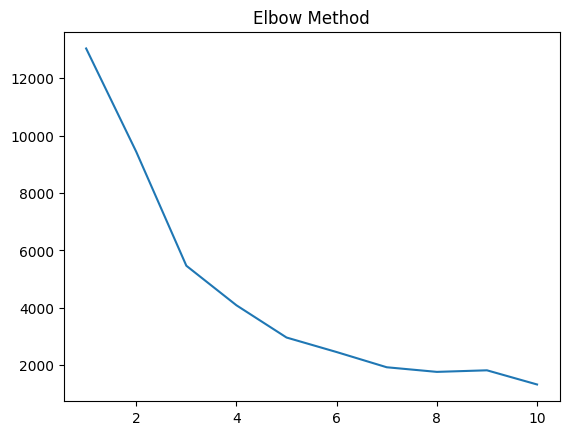

In [10]:
#Finding Optimal Clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.show()

In [11]:
#Applying K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [12]:
#Analyzing Clusters
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,16.133588,463.213740,11189.661718
1,44.513254,72.081842,1324.381800
2,249.476777,27.791469,490.446645
3,5.000000,2778.909091,135422.710909


In [13]:
#Adding PCA (Advanced Level Like Your Case Study)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)

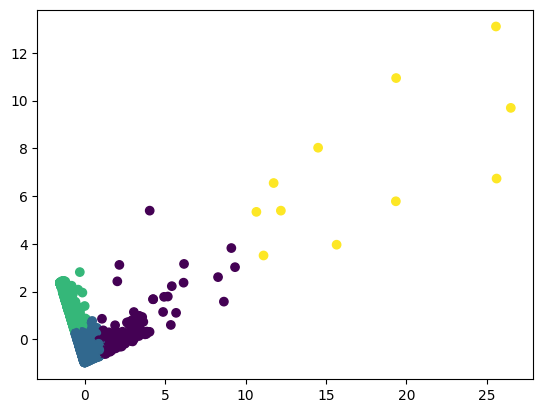

In [14]:
#Plotting PCA
plt.scatter(pca_result[:,0], pca_result[:,1], c=rfm['Cluster'])
plt.show()

In [15]:
#Model Evaluation
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(score)

# Good clustering:
# 0.5 – 0.7 → Good
# 0.7 → Excellent

0.6129090413189378


In [16]:
#Building Dashboard in Power BI
rfm.to_csv("customer_segments.csv")

In [17]:
import joblib
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [18]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
